In [1]:
import pandas as pd
import numpy as np
import os


## Phase 1: Building the Master Table

## #  Define the path to your data


In [2]:

import gc
import time

path = "dataset/raw/"

print(" Phase 1: Building the Master Table...")

 Phase 1: Building the Master Table...


## :LOAD DATA 

In [3]:

train = pd.read_csv(path + "train_v2.csv", dtype={'is_churn': 'int8'})
members = pd.read_csv(path + "members_v3.csv", dtype={'city': 'int8', 'registered_via': 'int8'})
transactions = pd.read_csv(path + "transactions_v2.csv")


# LOAD THE BIG FILE

In [4]:

logs = pd.read_csv(path + "user_logs_v2.csv", dtype={
    'num_25': 'int16', 'num_100': 'int16', 'num_unq': 'int16', 'total_secs': 'float32'
})

print(" All files loaded. Now summarizing behaviors...")

 All files loaded. Now summarizing behaviors...


# FEATURE ENGINEERING: Turn millions of log rows into 1 row per user

In [5]:

user_habits = logs.groupby('msno').agg({
    'num_100': 'sum', 
    'num_25': 'sum',
    'total_secs': 'sum'
}).reset_index()


# Create 'Completion Rate' (How many songs they finish vs skip)

In [6]:

user_habits['completion_rate'] = user_habits['num_100'] / (user_habits['num_25'] + 1)


# MERGE EVERYTHING

In [7]:

# We start with the labels (train) and glue the other pieces to it
master_df = train.merge(members, on='msno', how='left')
master_df = master_df.merge(user_habits, on='msno', how='left')


In [8]:
# Get only the last transaction per user (to see their current plan)
last_trans = transactions.sort_values('transaction_date').groupby('msno').tail(1)
master_df = master_df.merge(last_trans, on='msno', how='left')


# CLEAN UP:

In [9]:
#  Delete the huge raw files to free up your RAM
del logs, train, members, transactions, user_habits
gc.collect()
print("SUCCESS! Phase 1 Complete.")
print(f"Your Master Table has {master_df.shape[0]} users and {master_df.shape[1]} features.")
master_df.head()

SUCCESS! Phase 1 Complete.
Your Master Table has 970960 users and 19 features.


,msno,is_churn,city,bd,gender,registered_via,registration_init_time,num_100,num_25,total_secs,completion_rate,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1,5.0,28.0,male,3.0,20131223.0,318.0,186.0,80598.554688,1.700535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1,13.0,20.0,male,3.0,20131223.0,26.0,0.0,6986.508789,26.000000,36.0,30.0,180.0,180.0,0.0,20170311.0,20170411.0,0.0
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1,13.0,18.0,male,3.0,20131227.0,205.0,239.0,67810.468750,0.854167,15.0,90.0,300.0,300.0,0.0,20170314.0,20170615.0,0.0
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1,1.0,0.0,NaN,7.0,20140109.0,NaN,NaN,NaN,NaN,41.0,30.0,149.0,149.0,1.0,20151208.0,20180108.0,0.0
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1,13.0,35.0,female,7.0,20140125.0,962.0,9.0,239882.234375,96.200000,41.0,30.0,99.0,99.0,1.0,20170316.0,20170918.0,0.0


In [10]:
master_df.isnull().sum()

msno                           0
is_churn                       0
city                      109993
bd                        109993
gender                    582055
registered_via            109993
registration_init_time    109993
num_100                   216409
num_25                    216409
total_secs                216409
completion_rate           216409
payment_method_id          37382
payment_plan_days          37382
plan_list_price            37382
actual_amount_paid         37382
is_auto_renew              37382
transaction_date           37382
membership_expire_date     37382
is_cancel                  37382
dtype: int64

In [11]:
master_df.sample(20)

,msno,is_churn,city,bd,gender,registered_via,registration_init_time,num_100,num_25,total_secs,completion_rate,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
3549,MAwtdWeExQVzFr5OenwErMxvMVNaB8djHMDXQfvOFio=,1,1.0,0.0,NaN,7.0,20160307.0,286.0,49.0,7.722223e+04,5.720000,41.0,30.0,100.0,100.0,1.0,20170317.0,20170317.0,1.0
797459,1bT/xv/iKYKI5v0JBcM29wr1hRufQ2+MwyCmFv7Xass=,0,1.0,0.0,NaN,7.0,20160325.0,38.0,10.0,1.098185e+04,3.454545,41.0,30.0,149.0,149.0,1.0,20170324.0,20170424.0,0.0
248643,TO0qsGlIknRXlSToFb9BhgyWXgHjAhWEqECLlAl0pFE=,0,1.0,0.0,NaN,7.0,20150928.0,453.0,2.0,1.016666e+05,151.000000,41.0,30.0,99.0,99.0,1.0,20170331.0,20170430.0,0.0
621299,CoAioRLttR873fZlQ+i8O3MDwj6nDbFXLpc9bdHB/Us=,0,1.0,0.0,NaN,7.0,20160905.0,NaN,NaN,NaN,NaN,41.0,30.0,99.0,99.0,1.0,20170305.0,20170405.0,0.0
708910,ehZXcB1RyJXc3IXEM38sn6aA15D7Pb1HwRQqYCEuk3U=,0,4.0,0.0,NaN,9.0,20160221.0,475.0,136.0,1.249571e+05,3.467153,36.0,30.0,180.0,180.0,1.0,20170326.0,20170425.0,0.0
425179,LreRN7QNYq76U1XOMHvV+oA3RhhPbVZcxU5QohDm8XY=,0,1.0,0.0,NaN,7.0,20150707.0,45.0,20.0,1.218428e+04,2.142857,41.0,30.0,99.0,99.0,1.0,20170307.0,20170407.0,0.0
153762,1ZQkpM10WbCS8bpm3euOnYgAvH6slim+V7B/1n92bJc=,0,1.0,0.0,NaN,7.0,20100524.0,5470.0,10.0,1.188748e+06,497.272727,41.0,30.0,149.0,149.0,1.0,20170316.0,20170416.0,0.0
163221,7CBzE9a3fiLt19lXinvDozAexifEFTyBeZYw4e3tfO0=,0,13.0,23.0,female,9.0,20130111.0,109.0,49.0,3.087020e+04,2.180000,39.0,30.0,149.0,149.0,1.0,20170331.0,20170515.0,0.0
667285,CCcbd83IR8oaJUGXsPo4ZCEmtX9l8zHaN0gBsGKumTo=,0,11.0,34.0,female,3.0,20130225.0,6252.0,40.0,1.481629e+06,152.487805,39.0,30.0,149.0,149.0,1.0,20170331.0,20170511.0,0.0
276417,n3uLY/DaXSKGuu9tQCxomsMrd2V3tzYW+YPdXlXurUs=,0,1.0,0.0,NaN,7.0,20160715.0,NaN,NaN,NaN,NaN,41.0,30.0,100.0,100.0,1.0,20170314.0,20170414.0,0.0


# __________

In [12]:
print("Master_DF Final Audit")

Master_DF Final Audit


In [13]:

# 1. Check the Shape (Should be around 970k rows, 19 columns)
print(f"Total Customers: {master_df.shape[0]}")
print(f"Total Features: {master_df.shape[1]}")


Total Customers: 970960
Total Features: 19


In [14]:

# 2. Does our 'Completion Rate' make sense? 
# We want to see if people who CHURN (1) have a lower completion rate than people who STAY (0).
print("\n Behavioral Analysis (Mean Values):")
audit = master_df.groupby('is_churn')[['completion_rate', 'total_secs', 'actual_amount_paid']].mean()
print(audit)


 Behavioral Analysis (Mean Values):
          completion_rate     total_secs  actual_amount_paid
is_churn                                                    
0               15.133856  141113.078125          129.072723
1               12.144830  126291.226562          383.407151


In [15]:
print("Checking the Behavioral Signal...")

# Compare the Average Completion Rate for Stayers (0) vs. Churners (1)
signal = master_df.groupby('is_churn')['completion_rate'].mean().round(4)

print("\nAverage Completion Rate:")
print(f"Loyal Customers (0): {signal[0]}")
print(f"Churning Customers (1): {signal[1]}")

if signal[0] > signal[1]:
    print("\n SIGNAL DETECTED: Loyal customers finish more songs. The AI will learn this!")
else:
    print("\nWEAK SIGNAL: The behaviors look similar. The AI might struggle.")
    

Checking the Behavioral Signal...

Average Completion Rate:
Loyal Customers (0): 15.1339
Churning Customers (1): 12.1448

 SIGNAL DETECTED: Loyal customers finish more songs. The AI will learn this!


In [16]:
!pip install xgboost

In [17]:
# 1. Select the features (X) and the label (y)
# We drop IDs and dates because they aren't "patterns" the AI can useabs
features_to_use = [
    'city', 'bd', 'registered_via', 'num_100', 'num_25', 
    'total_secs', 'completion_rate', 'payment_plan_days', 
    'plan_list_price', 'actual_amount_paid', 'is_auto_renew', 'is_cancel'
]
X = master_df[features_to_use]
y = master_df['is_churn']

In [18]:
# 2. The 80/20 Split
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {X_train.shape[0]} users. Testing on {X_test.shape[0]} users...")


Training on 776768 users. Testing on 194192 users...


In [19]:
# 3. Create the XGBoost Model
model = XGBClassifier(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# 4. START TRAINING (The "Study Session")
print("\n🧠 AI is analyzing patterns... please wait...")
model.fit(X_train, y_train)



🧠 AI is analyzing patterns... please wait...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [20]:
# 5. TEST THE AI (The "Final Exam")
from sklearn.metrics import accuracy_score,classification_report
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("  --- PHASE 3 COMPLETE --- ")
print(f"AI Model Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

  --- PHASE 3 COMPLETE --- 
AI Model Accuracy: 96.41%

Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    176742
           1       0.85      0.73      0.79     17450

    accuracy                           0.96    194192
   macro avg       0.91      0.86      0.88    194192
weighted avg       0.96      0.96      0.96    194192



📉 Phase 4: Why are they leaving? (Feature Importance)


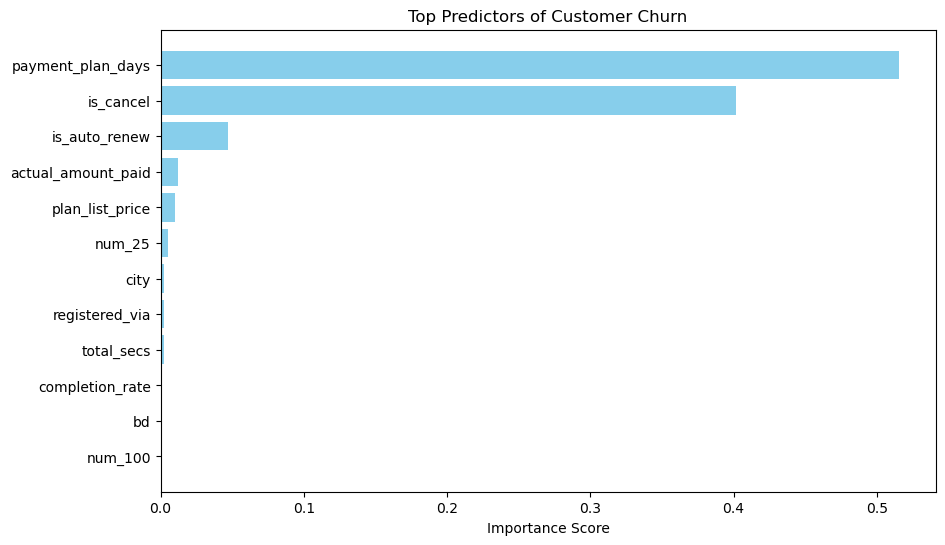


🏆 Top 3 Reasons for Churn:
              Feature  Importance
7   payment_plan_days    0.515240
11          is_cancel    0.401977
10      is_auto_renew    0.047338


In [21]:
import matplotlib.pyplot as plt
import pandas as pd

print("📉 Phase 4: Why are they leaving? (Feature Importance)")

# 1. Get the "Weight" of each feature from the AI
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2. Plot the results
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis() # Put the most important at the top
plt.title("Top Predictors of Customer Churn")
plt.xlabel("Importance Score")
plt.show()

# 3. Print the Top 3
print("\n🏆 Top 3 Reasons for Churn:")
print(importance_df.head(3))

In [22]:
import pickle

# Save the model to a file
with open('churn_model_v1.pkl', 'wb') as f:
    pickle.dump(model, f)

print(" Model saved as 'churn_model_v1.pkl'!")
print("PROJECT COMPLETE! You just built a 96% accurate Churn Prediction System.")

 Model saved as 'churn_model_v1.pkl'!
PROJECT COMPLETE! You just built a 96% accurate Churn Prediction System.


In [23]:
import numpy as np

def predict_churn(city, bd, num_100, num_25, plan_days, price, auto_renew):
    """
    Simulates a single customer and asks the AI for a prediction.
    """
    # 1. Calculate the 'completion_rate' just like we did in the logs
    comp_rate = num_100 / (num_25 + 1)
    
    # 2. Arrange the data exactly like the AI was trained (12 features)
    # We use 0 for the features we didn't include in this simple test
    # Order: city, bd, registered_via, num_100, num_25, total_secs, completion_rate, 
    #        payment_plan_days, plan_list_price, actual_amount_paid, is_auto_renew, is_cancel
    
    user_data = np.array([[
        city, bd, 7, num_100, num_25, (num_100 * 240), comp_rate, 
        plan_days, price, price, auto_renew, 0
    ]])
    
    # 3. Get the probability from the AI
    prob = model.predict_proba(user_data)[0][1]
    prediction = "CHURN RISK" if prob > 0.5 else " LOYAL"
    
    print(f"--- AI Analysis Report ---")
    print(f"Customer Status: {prediction}")
    print(f"Probability of Leaving: {prob*100:.2f}%")

# --- TEST CASE 1: The 'Tourists' (Short plan, lots of skips) ---
print("Testing User A (Short plan, 50 skips):")
predict_churn(city=1, bd=20, num_100=10, num_25=50, plan_days=7, price=99, auto_renew=0)

# --- TEST CASE 2: The 'Loyal' (Long plan, finishes songs) ---
print("\nTesting User B (30-day plan, 100 finishes, auto-renew ON):")
predict_churn(city=1, bd=35, num_100=100, num_25=5, plan_days=30, price=149, auto_renew=1)

Testing User A (Short plan, 50 skips):
--- AI Analysis Report ---
Customer Status: CHURN RISK
Probability of Leaving: 58.29%

Testing User B (30-day plan, 100 finishes, auto-renew ON):
--- AI Analysis Report ---
Customer Status:  LOYAL
Probability of Leaving: 2.50%


In [24]:
!pip install shap

📊 SHAP MODERN ANALYSIS: Why is User A leaving?


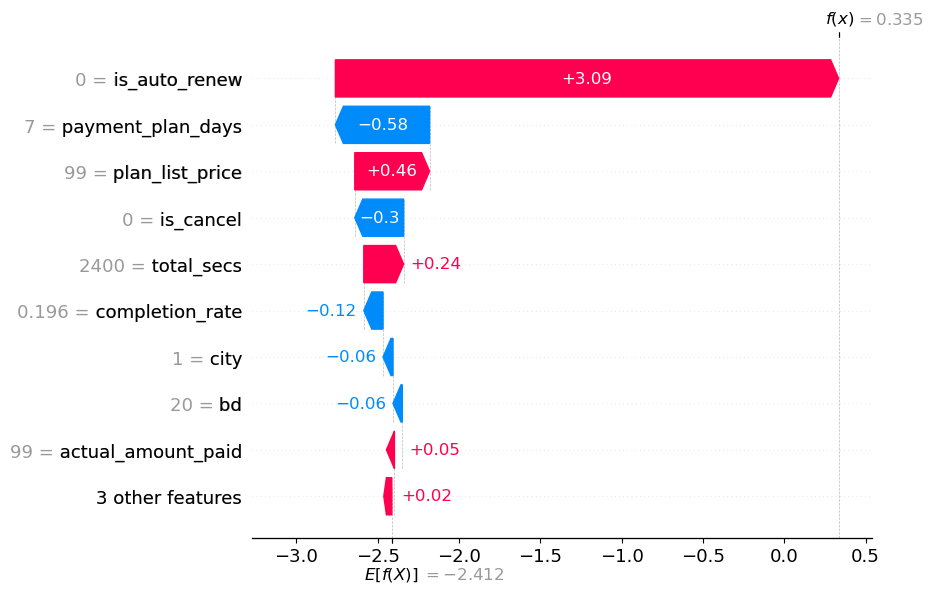

In [25]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. Initialize Explainer
explainer = shap.TreeExplainer(model)

# 2. Re-create User A's data (The "Tourist" with the 7-day plan)
user_a_features = np.array([[1, 20, 7, 10, 50, (10 * 240), (10/51), 7, 99, 99, 0, 0]])

# 3. Get SHAP values
# Note: For XGBoost, SHAP sometimes returns a list [loyalty_score, churn_score]
# We want index [1] for Churn
shap_values_all = explainer.shap_values(user_a_features)
base_value = explainer.expected_value

# 4. Create a "Modern Explanation Object"
# This is how SHAP wants us to do it now!
exp = shap.Explanation(
    values=shap_values_all[1] if isinstance(shap_values_all, list) else shap_values_all[0], 
    base_values=base_value[1] if isinstance(base_value, (np.ndarray, list)) else base_value,
    data=user_a_features[0],
    feature_names=[
        'city', 'bd', 'registered_via', 'num_100', 'num_25', 
        'total_secs', 'completion_rate', 'payment_plan_days', 
        'plan_list_price', 'actual_amount_paid', 'is_auto_renew', 'is_cancel'
    ]
)

# 5. THE WATERFALL PLOT
print("📊 SHAP MODERN ANALYSIS: Why is User A leaving?")
shap.plots.waterfall(exp)

In [26]:
%pip install langchain langchain-community langchain-google-genai

Note: you may need to restart the kernel to use updated packages.


In [27]:
%pip install langchain-core

Note: you may need to restart the kernel to use updated packages.


In [28]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate

# Load API key securely from environment variable
# Set this before running: export GOOGLE_API_KEY='your_key_here'
# Or paste your key in the Streamlit sidebar when using app.py
api_key = os.environ.get('GOOGLE_API_KEY', '')
if not api_key:
    print('⚠️  Please set GOOGLE_API_KEY environment variable')
    print('   export GOOGLE_API_KEY='your_key_here'')
else:
    os.environ['GOOGLE_API_KEY'] = api_key

# Setup Gemini Model
llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash', temperature=0.7)

🤖 AGENT RESPONSE:
--------------------------------------------------
[{'type': 'text', 'text': 'I noticed your auto-renew is currently disabled and I’d like to offer you an exclusive loyalty discount to ensure your service continues without interruption. Simply re-enable auto-renewal in your account settings today to lock in this special rate and maintain seamless access to all your premium benefits.', 'extras': {'signature': 'EuoUCucUAb4+9vvCc0mqbTc1cbkB/LkVu3MuF5l4YYftC/sMDOrt0EG7XDEHwrxjqD9GTe7qeuT+oYJwS48VRHZzxuan6EyCdm/AxxVNKwFGpaf5cMwVCJbnmQcBT8pl3GRIkmT4w1QLPGfI0hiP96BB6V6vGe+WVbFNk/IF189tUgFzSfa9DQtmQQEqlU8974bqI036VY8MRjaqZZJbO1Wh6f/TM5ZiOabHVBEBb84o5laEQgib8O/a4O5Sl0GxT/EjVRpWe2a1sIR8JrNVgaH1SgV6PzSkjRTWuPEcsf3rA+HNwBdj2bdyIzALFM7gQl3Z29w6L0EODJEMYcAjaUsSYu0miI1/sR9W9gkSxtdea8X4cQ8WdcTGRFejWKNr/e9EY4UNwZybVVGhjjjV3u396ZYnF84tucDfzB2PWs690SsQ5AAgdHvloERfFDGa0h+fOSUaMAscuY2j/Oko21Kcaje97SaFAJAnJ0k6z1NYRaNnJkXoVaSK2BM44a9bxZZO4tJFtQDMAs5UJLcaAQUmD83XKuJsOxGQC0RUOkHB29cIGn3HnFtgb

In [29]:
import pickle

# Save your trained XGBoost model as a file
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save the top 100 rows of your data for the UI to display
master_df.head(100).to_csv('ui_data.csv', index=False)

print("✅ SUCCESS: 'churn_model.pkl' and 'ui_data.csv' are now in your folder!")

✅ SUCCESS: 'churn_model.pkl' and 'ui_data.csv' are now in your folder!


In [30]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle
import shap
import matplotlib.pyplot as plt
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
import os

st.set_page_config(page_title="Churn Commander AI", layout="wide")
st.title("🎧 Music OTT: Churn Prediction & AI Retention")

# Load your Phase 3 brain
model = pickle.load(open('churn_model.pkl', 'rb'))
df = pd.read_csv('ui_data.csv')

# --- SIDEBAR ---
st.sidebar.header("Select a Customer")
user_idx = st.sidebar.selectbox("Choose Row Index", df.index)
user_row = df.iloc[[user_idx]].drop('is_churn', axis=1)

# --- MAIN DASHBOARD ---
col1, col2 = st.columns(2)

with col1:
    st.subheader("Prediction Result")
    prob = model.predict_proba(user_row)[0][1]
    risk_color = "red" if prob > 0.5 else "green"
    st.markdown(f"<h1 style='color: {risk_color};'>{round(prob*100, 2)}% Churn Risk</h1>", unsafe_allow_html=True)
    
    st.subheader("🔍 SHAP Explanation")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(user_row)
    fig, ax = plt.subplots()
    shap.plots.waterfall(shap.Explanation(values=shap_values[0], 
                                         base_values=explainer.expected_value, 
                                         data=user_row.iloc[0], 
                                         feature_names=user_row.columns))
    st.pyplot(fig)

with col2:
    st.subheader("🤖 AI Retention Agent")
    api_key = st.text_input("Enter Gemini API Key", type="password")
    if st.button("Generate Save Strategy"):
        if api_key:
            os.environ["GOOGLE_API_KEY"] = api_key
            llm = ChatGoogleGenerativeAI(model="gemini-1.5-pro")
            prompt = PromptTemplate.from_template("Write a 2-sentence offer for a user with {p}% risk because their Auto-Renew is OFF.")
            chain = prompt | llm
            response = chain.invoke({"p": round(prob*100, 1)})
            st.info(response.content)
        else:
            st.warning("Please enter your API Key first.")

Overwriting app.py
